# **AI Dry Eye Risk Assessment & Lifestyle Recommendation System**

## *Exploratory Data Analysis (EDA)*

### *Objective*

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Dry Eye Disease dataset.

During this phase we will:

- Understand the dataset structure
- Explore numerical and categorical features
- Identify missing values
- Detect duplicate records
- Check statistical properties
- Detect outliers
- Analyze feature distributions
- Explore relationships between variables
- Prepare the dataset for Machine Learning

This notebook focuses only on understanding the data before any preprocessing or model training.

### **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Dataset**

In [2]:
df = pd.read_csv(r'..\data\raw\Dry_Eye_Dataset.csv')
df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y


## ***Observation***

The dataset has been loaded successfully.

The first five rows indicate that:

- Both numerical and categorical features are present.
- Blood Pressure is stored as a single text column.
- The target variable is **Dry Eye Disease**.
- No obvious formatting issues are visible.

### **Initial Dataset Exploration**

In [3]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.shape

Rows : 20000
Columns : 26


(20000, 26)

## ***Observation***

The dataset contains:

- 20,000 observations
- 26 features

This is a reasonably large dataset for training machine learning classification models.

### **Data Quality Assessment**

Before performing any analysis, it is important to verify the quality of the dataset.

In this section, we will check:

- Missing Values
- Duplicate Records

Ensuring data quality helps build reliable machine learning models and reduces the risk of incorrect analysis.

In [4]:
# Missing Values
missing_values = df.isnull().sum()

# Duplicate Records
duplicate_records = df.duplicated().sum()

print("Missing Values")
print(missing_values)

print("\nDuplicate Records")
print(duplicate_records)

Missing Values
Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64

Duplicate Records
0


## ****Observation****

The data quality assessment shows that:

- No missing values were found in any feature.
- No duplicate records were detected.

This indicates that the dataset is clean and complete. Therefore, no data cleaning is required before proceeding with exploratory data analysis and preprocessing.

### **Dataset Information**

The `info()` function provides a concise summary of the dataset. It helps us understand the overall structure of the data before performing detailed analysis.

The information includes:

- Total number of rows and columns
- Feature names
- Data types of each feature
- Number of non-null values
- Memory usage

This step helps identify potential data quality issues such as missing values or incorrect data types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 13  Feel sleepy duri

## ****Observation****

From the dataset information, we observed the following:

- The dataset contains **20,000 records** and **26 features**.
- Numerical features are stored as **integer (`int64`)** and **floating-point (`float64`)** data types.
- Categorical features are stored as the **object** data type.
- Every feature contains **20,000 non-null values**, indicating that there are no missing values.
- The dataset occupies approximately **4 MB** of memory, making it efficient to process on a standard computer.

Overall, the dataset appears to be well-structured and suitable for further exploratory data analysis and machine learning preprocessing.

### **Statistical Summary**

The `describe()` function provides descriptive statistics for both numerical and categorical features.

For numerical features, it reports statistics such as:

- Count
- Mean
- Standard Deviation
- Minimum and Maximum values
- Quartiles (25%, 50%, and 75%)

For categorical features, it provides:

- Number of unique categories
- Most frequent category
- Frequency of the most common category

This summary helps us understand the distribution, central tendency, and variability of the dataset before moving to detailed visual analysis.

In [6]:
df.describe()

,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,Average screen time
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,31.422800,6.998245,2.997250,2.993750,79.912200,10536.900000,90.069750,174.865900,74.891850,5.519885
std,8.103717,1.731723,1.412283,1.407235,11.808279,5752.729186,52.317283,14.719903,14.733839,2.606305
min,18.000000,4.000000,1.000000,1.000000,60.000000,1000.000000,0.000000,150.000000,50.000000,1.000000
25%,24.000000,5.500000,2.000000,2.000000,70.000000,6000.000000,45.000000,162.000000,62.000000,3.300000
50%,31.000000,7.000000,3.000000,3.000000,80.000000,11000.000000,91.000000,175.000000,75.000000,5.500000
75%,39.000000,8.500000,4.000000,4.000000,90.000000,16000.000000,135.000000,188.000000,88.000000,7.800000
max,45.000000,10.000000,5.000000,5.000000,100.000000,20000.000000,180.000000,200.000000,100.000000,10.000000


## ****Observation****

The statistical summary provides several useful insights about the dataset:

- All numerical features contain **20,000 valid observations**, confirming the absence of missing values.
- Most numerical variables fall within realistic ranges, suggesting that the dataset does not contain obvious invalid entries.
- The mean and median values are generally close for several numerical features, indicating relatively balanced distributions.
- Categorical features mostly contain **two unique categories** (such as **Y/N** or **M/F**), making them straightforward to encode during preprocessing.
- The **Blood Pressure** feature has a large number of unique values because it combines systolic and diastolic measurements into a single text column. This feature will be transformed into separate numerical variables during preprocessing.

Overall, the statistical summary suggests that the dataset is clean, well-organized, and ready for detailed exploratory analysis, including outlier detection and feature distribution analysis.

## **Outlier Detection**
>Outliers were identified using the Interquartile Range (IQR) method and verified through boxplots to assess the quality of numerical features.

In [7]:
select_numeric_columns = df.select_dtypes(np.number).columns
outliers_result = []

for column in select_numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) | (df[column] > upper_bound)
    ].shape[0]

    outliers_result.append({'column': column, 'outliers': outliers})

outliers_df = pd.DataFrame(outliers_result)
outliers_df

,column,outliers
0,Age,0
1,Sleep duration,0
2,Sleep quality,0
3,Stress level,0
4,Heart rate,0
5,Daily steps,0
6,Physical activity,0
7,Height,0
8,Weight,0
9,Average screen time,0


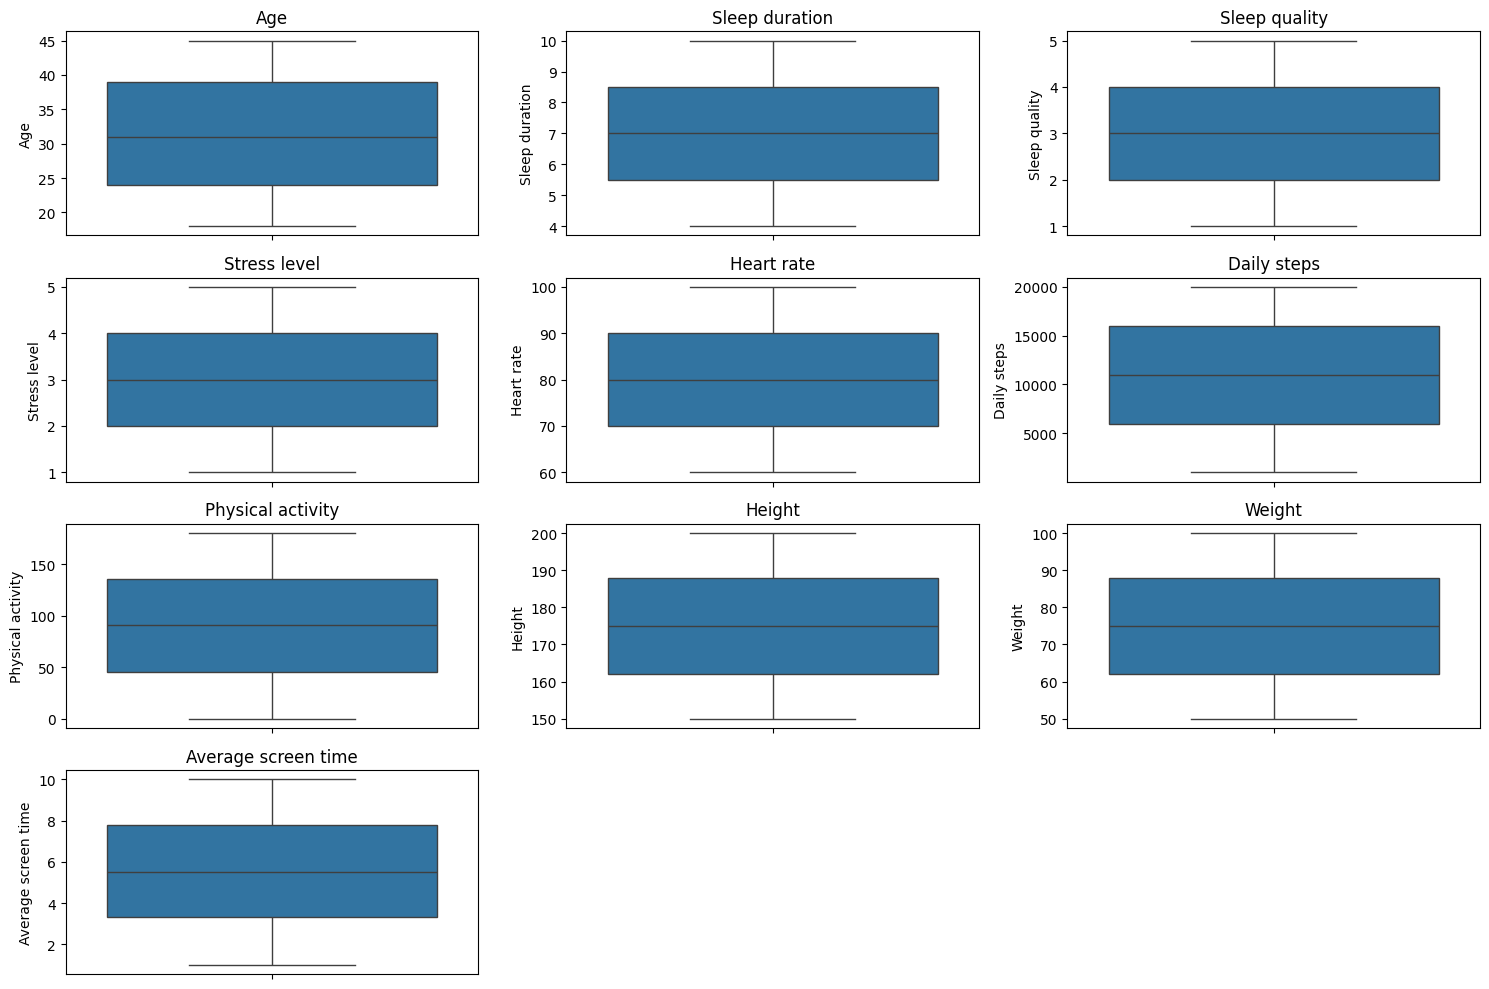

In [8]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## **Observation**

- No outliers were detected in any numerical feature using the IQR method.
- Boxplots also confirmed the absence of extreme values.
- The numerical features appear clean and do not require outlier treatment.
- This behavior is expected because the dataset appears to be synthetically generated.

# **Numerical Feature Distribution**
>Histograms were plotted to examine the distribution of numerical features and identify any unusual patterns such as skewness or irregular value distributions.

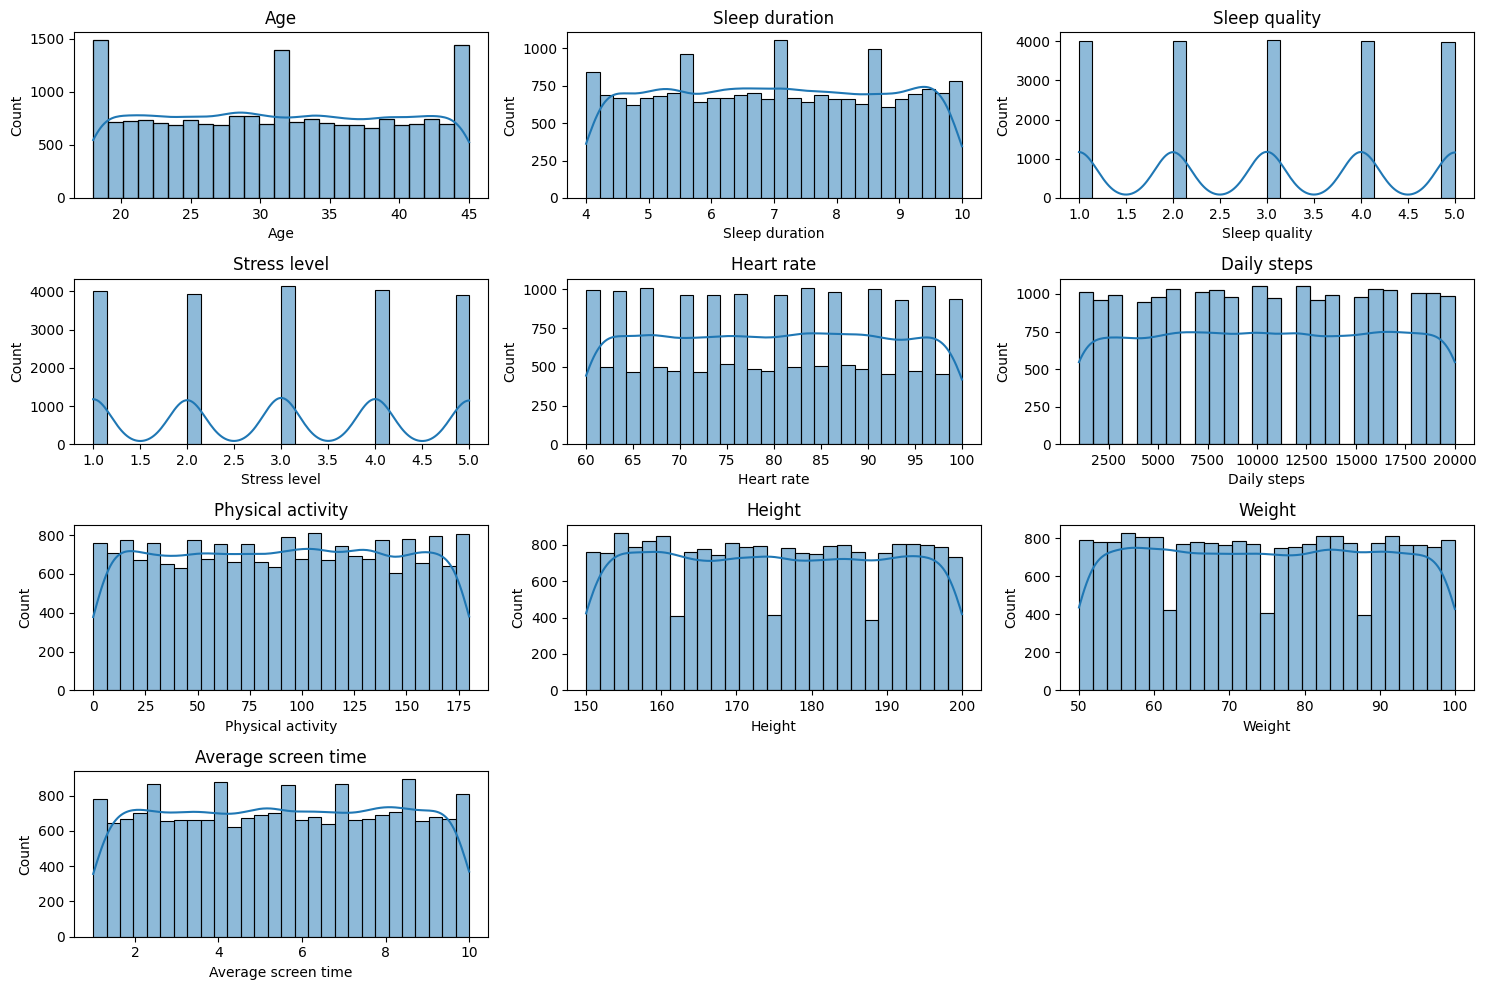

In [9]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(x=df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## **Observation**

- Most numerical features show approximately uniform distributions.
- No unusual peaks or highly skewed distributions were observed.
- The values fall within reasonable ranges without unexpected patterns.
- The distributions indicate that the numerical data is clean and suitable for machine learning.
- The nearly uniform distributions suggest that the dataset may be synthetically generated or carefully curated.

# **Correlation Analysis**

> A correlation heatmap was generated to examine the relationships between numerical features and identify potential multicollinearity.

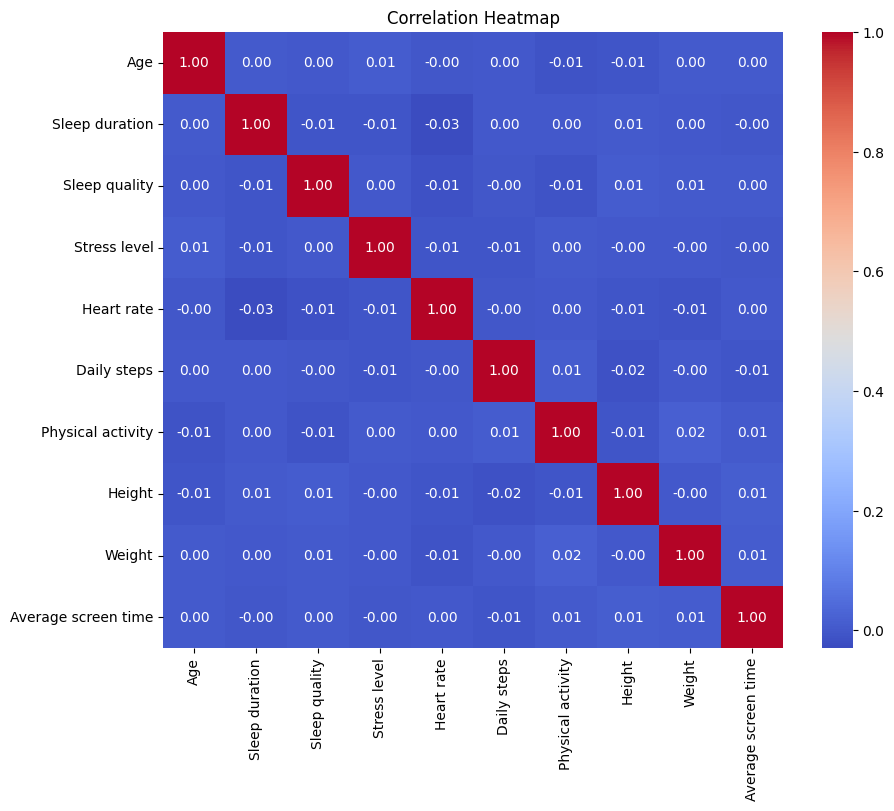

In [10]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## **Observation**

- Most numerical features show weak to moderate correlations.
- No strong correlations were observed between the numerical features.
- No evidence of multicollinearity was found.
- Therefore, no numerical feature needs to be removed based on the correlation analysis.

# **Categorical Feature Analysis**

>Categorical features were analyzed to identify the number of unique categories and verify the consistency of categorical values before encoding.

In [11]:
categorical_cols = df.select_dtypes(include="object").columns

summary = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols],
    "Categories": [", ".join(map(str, df[col].unique()[:5])) for col in categorical_cols]
})

summary

,Column,Unique Values,Categories
0,Gender,2,"F, M"
1,Blood pressure,1581,"137/89, 108/64, 134/81, 110/90, 99/67"
2,Sleep disorder,2,"Y, N"
3,Wake up during night,2,"N, Y"
4,Feel sleepy during day,2,"N, Y"
5,Caffeine consumption,2,"N, Y"
6,Alcohol consumption,2,"N, Y"
7,Smoking,2,"N, Y"
8,Medical issue,2,"Y, N"
9,Ongoing medication,2,"Y, N"


## **Observation**

- Most categorical features contain only two categories (e.g., **Y/N** or **M/F**).
- The categorical values are consistent, with no unexpected or invalid labels observed.
- The **Blood Pressure** feature contains many unique values because it stores systolic and diastolic measurements in a single column.
- The dataset is well-structured, and the categorical features are suitable for encoding during preprocessing.

# **Target Variable Analysis**

>The target variable was analyzed to understand the class distribution and identify whether the dataset is balanced or imbalanced before model training.

In [12]:
# Unique Classes
print(df["Dry Eye Disease"].unique())

# Class Counts
print(df["Dry Eye Disease"].value_counts())

# Class Percentage
print((df["Dry Eye Disease"].value_counts(normalize=True) * 100).round(2))

['Y' 'N']
Dry Eye Disease
Y    13037
N     6963
Name: count, dtype: int64
Dry Eye Disease
Y    65.18
N    34.82
Name: proportion, dtype: float64


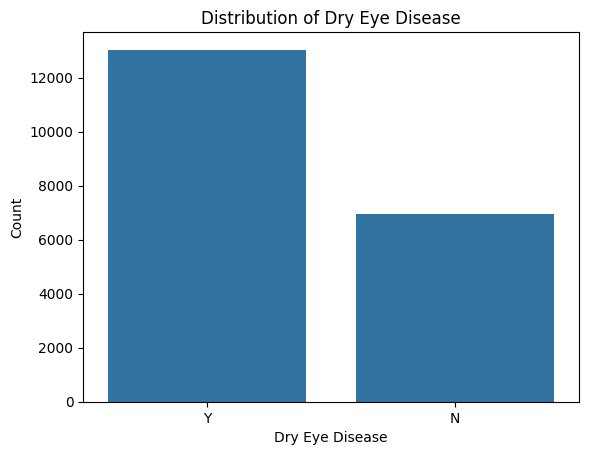

In [13]:
# Visualize Target Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Dry Eye Disease")

plt.title("Distribution of Dry Eye Disease")
plt.xlabel("Dry Eye Disease")
plt.ylabel("Count")

plt.show()

## **Observation**

- The target variable contains two classes: **Yes (Y)** and **No (N)**.
- Approximately **65%** of the samples belong to the positive class (Dry Eye Disease), while **35%** belong to the negative class.
- This indicates a **moderately imbalanced** dataset.
- Therefore, model evaluation should not rely solely on accuracy. Additional metrics such as Precision, Recall, F1-score, and ROC-AUC should also be considered.

## **Section 2 — Data Preprocessing**

### **Step 1: Blood Pressure Feature Engineering**

The Blood pressure column was originally stored as a single text feature (e.g., "120/80"). Machine learning models cannot directly utilize this format because it combines two different physiological measurements into one string.

Therefore, the feature was split into two independent numerical variables:

Systolic_BP → Upper blood pressure (first value)
Diastolic_BP → Lower blood pressure (second value)

After extracting both values, the original Blood pressure column was removed since it no longer provides additional information.

In [14]:
df[['Systolic_BP', 'Diastolic_BP']] = (
    df['Blood pressure']
    .str.split('/', expand=True)
    .astype(int)
)

In [15]:
df.drop(columns=['Blood pressure'], axis=1 , inplace=True)

In [16]:
df[['Systolic_BP',
    'Diastolic_BP']].head()

,Systolic_BP,Diastolic_BP
0,137,89
1,108,64
2,134,81
3,110,90
4,99,67


### **Step 2: Categorical Feature Encoding**

Machine learning algorithms cannot directly process categorical (text) values.
Therefore, all binary categorical features are converted into numerical values
using the `map()` function.

Encoding Scheme:

- Female (F) → 0
- Male (M) → 1
- No (N) → 0
- Yes (Y) → 1

Since all categorical variables in this dataset are binary, the `map()` method
is simple, efficient, and easy to interpret.

In [17]:
# Encode Gender
df["Gender"] = df["Gender"].map({"F": 0, "M": 1})

# Encode all Y/N columns
binary_columns = [
    "Sleep disorder",
    "Wake up during night",
    "Feel sleepy during day",
    "Caffeine consumption",
    "Alcohol consumption",
    "Smoking",
    "Medical issue",
    "Ongoing medication",
    "Smart device before bed",
    "Blue-light filter",
    "Discomfort Eye-strain",
    "Redness in eye",
    "Itchiness/Irritation in eye",
    "Dry Eye Disease"
]

for col in binary_columns:
    print(f"{col}: {df[col].unique()}")

Sleep disorder: ['Y' 'N']
Wake up during night: ['N' 'Y']
Feel sleepy during day: ['N' 'Y']
Caffeine consumption: ['N' 'Y']
Alcohol consumption: ['N' 'Y']
Smoking: ['N' 'Y']
Medical issue: ['Y' 'N']
Ongoing medication: ['Y' 'N']
Smart device before bed: ['N' 'Y']
Blue-light filter: ['N' 'Y']
Discomfort Eye-strain: ['Y' 'N']
Redness in eye: ['Y' 'N']
Itchiness/Irritation in eye: ['N' 'Y']
Dry Eye Disease: ['Y' 'N']


In [18]:
# Encode all Y/N columns
binary_columns = [
    "Sleep disorder",
    "Wake up during night",
    "Feel sleepy during day",
    "Caffeine consumption",
    "Alcohol consumption",
    "Smoking",
    "Medical issue",
    "Ongoing medication",
    "Smart device before bed",
    "Blue-light filter",
    "Discomfort Eye-strain",
    "Redness in eye",
    "Itchiness/Irritation in eye",
    "Dry Eye Disease"
]
for col in binary_columns:
    df[col] = df[col].map({"N": 0, "Y": 1})


In [19]:
df[binary_columns + ["Gender"]].head()

,Sleep disorder,Wake up during night,Feel sleepy during day,Caffeine consumption,Alcohol consumption,Smoking,Medical issue,Ongoing medication,Smart device before bed,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease,Gender
0,1,0,0,0,0,0,1,1,0,0,1,1,0,1,0
1,0,0,0,0,1,0,1,1,0,1,0,0,1,1,1
2,1,1,0,1,1,0,0,0,1,0,1,0,0,0,0
3,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0
4,0,1,0,0,0,0,1,0,0,0,1,1,0,1,0


# **Step 3: Save the Processed Dataset**

After completing Exploratory Data Analysis (EDA) and basic preprocessing, the cleaned dataset is saved for the next stage of the machine learning pipeline.

The saved dataset includes:

- Cleaned feature names
- Split Blood Pressure into Systolic_BP and Diastolic_BP
- Encoded binary categorical variables
- Original EDA remains reproducible
- Ready for model training

Saving the processed dataset avoids repeating preprocessing steps and keeps the project organized.

The next notebook (**02_model_training.ipynb**) will load this processed dataset for feature selection, train-test splitting, feature scaling (where required), model training, evaluation, and comparison.

In [20]:
df.to_csv("../data/processed/dry_eye_clean.csv", index=False)

### **Observation**

The processed dataset has been successfully saved.

This file will be used in the next notebook to build, evaluate, and compare multiple machine learning models without repeating the preprocessing steps.

# 📌 **EDA Summary**

> Exploratory Data Analysis (EDA) and basic preprocessing were completed successfully. The dataset was explored, cleaned, validated, and prepared for the machine learning pipeline.

## **Key Findings**

- The dataset contains **20,000 records** and **26 features**, providing sufficient data for model development.
- No missing values were found in any feature.
- No duplicate records were detected.
- Numerical features were checked for outliers using the **IQR method** and boxplots. No significant outliers requiring treatment were observed.
- Histograms indicated that most numerical features have clean and relatively uniform distributions.
- All binary categorical features contained valid and consistent categories (`Y/N` and `F/M`).
- The **Blood Pressure** feature was successfully split into two independent numerical features:
  - `Systolic_BP`
  - `Diastolic_BP`
- All binary categorical variables were encoded into numerical values using the `map()` function.
- Correlation analysis showed **no evidence of severe multicollinearity** among numerical features.

## **Dataset Limitation**

Although the dataset is well-structured and suitable for learning the complete machine learning workflow, its highly balanced distributions and uniformly generated feature patterns suggest that it may be partially synthetic or artificially generated. As a result, model performance on this dataset may not fully reflect performance on real-world clinical data.

## **Output**

The fully processed dataset has been saved as:

```text
data/processed/dry_eye_clean.csv
```

This processed dataset will be used in the next notebook (`02_model_training.ipynb`) for:

- Feature and target separation
- Train-test splitting
- Feature scaling (where required)
- Model training
- Model evaluation
- Model comparison
- Saving the best-performing model